In [1]:
import glob
import os
import sys
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

cmap = cm.inferno

# load data from parquet files
experiment_df = pl.read_parquet('./Results/optimisation_experiments.parquet')
best_policy_df = pl.read_parquet('./Results/optimisation_best_policies.parquet')
outcomes_df = pl.read_parquet('./Results/optimisation_outcomes.parquet')

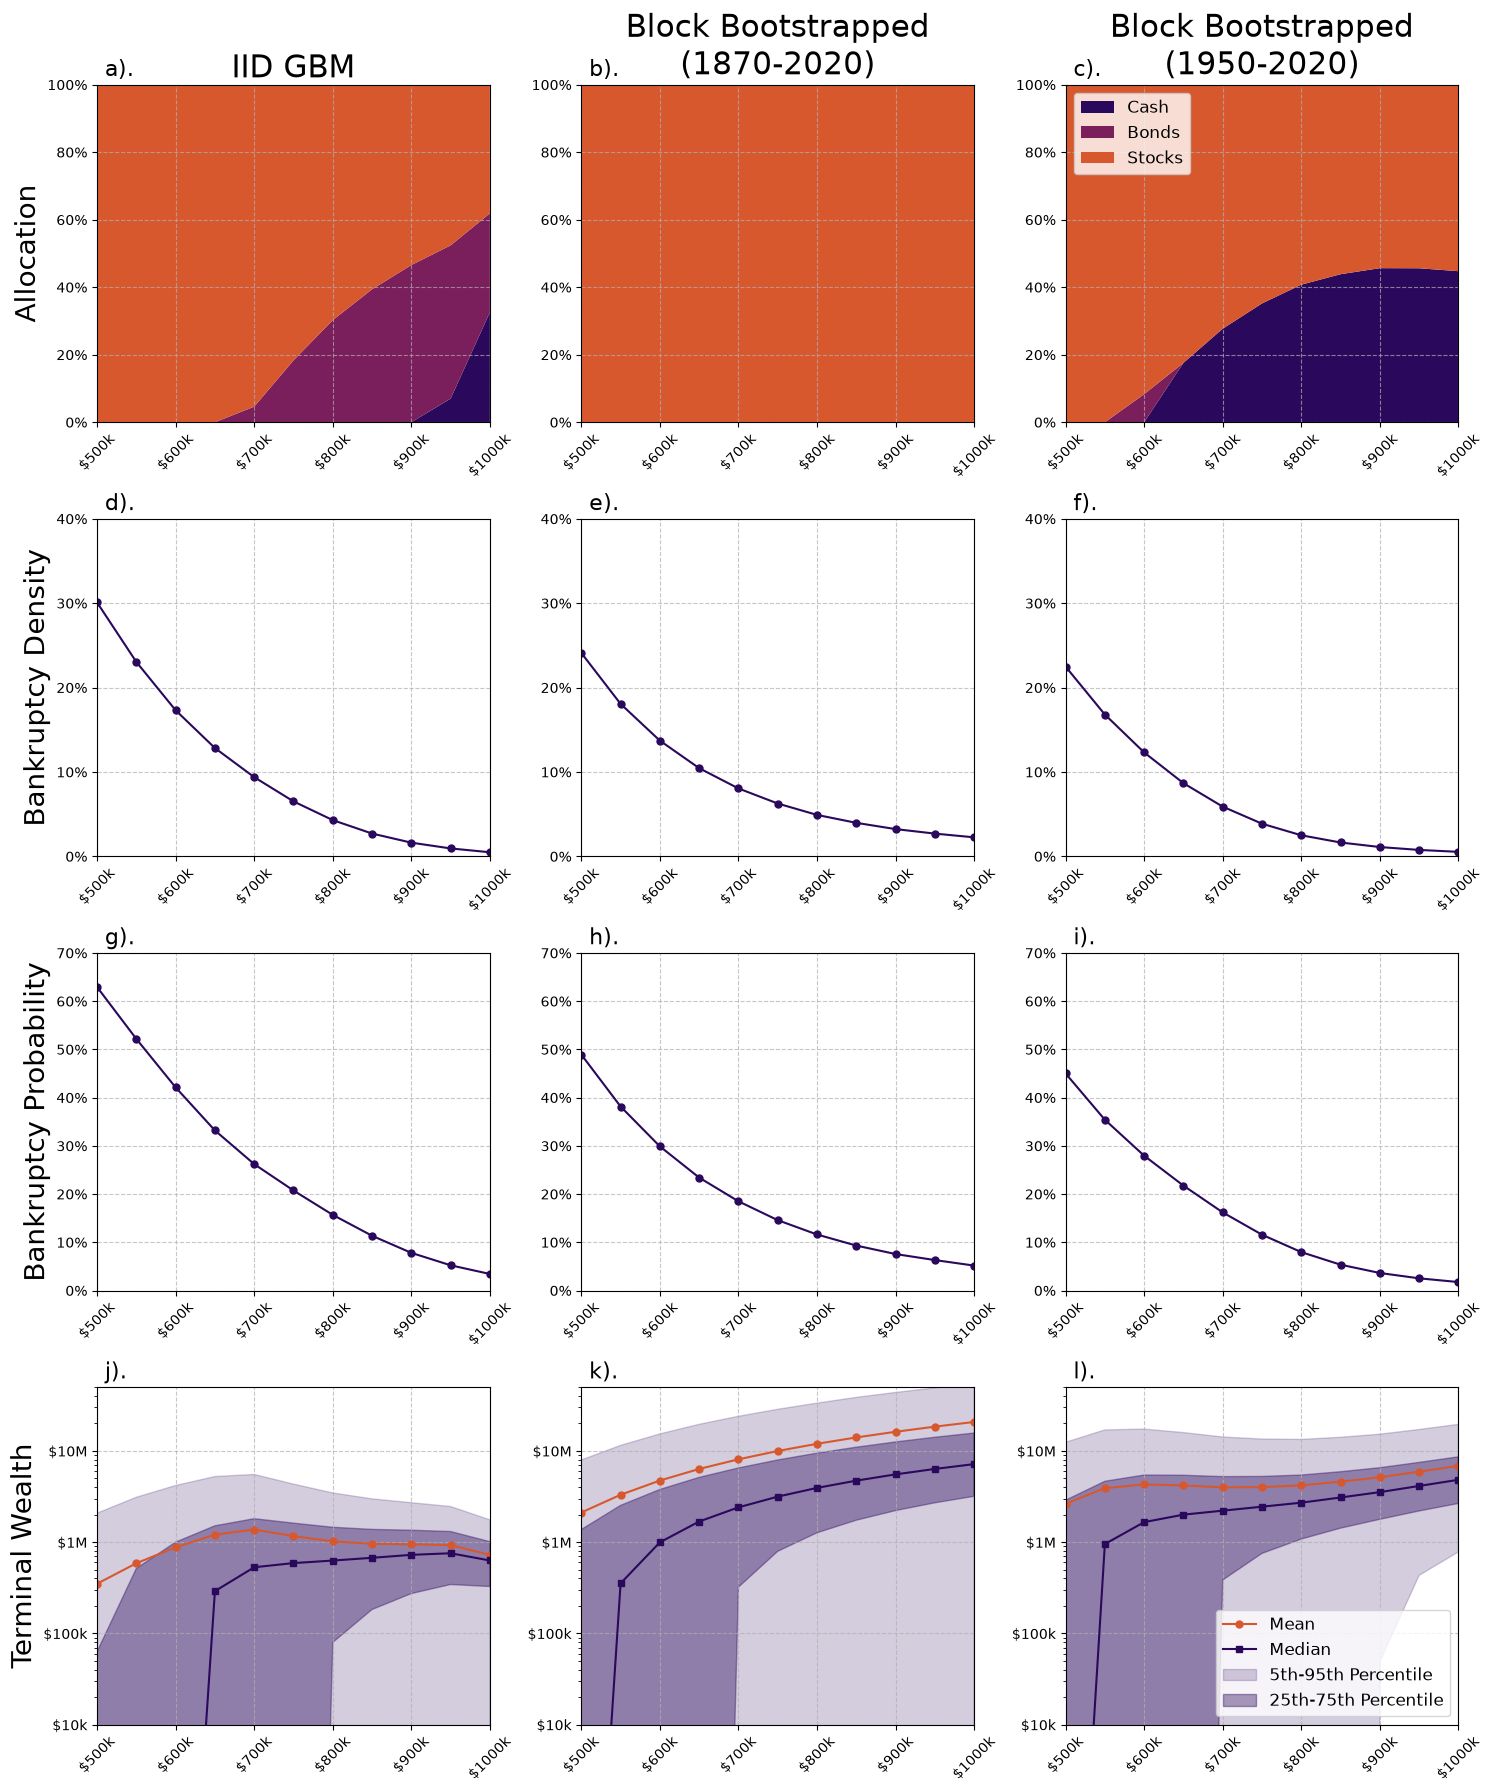

In [2]:
"""
plot: Fixed Allocation Strategies Optimised Across a Range of Fixed Initial Wealth Levels
Titles -> sampler name
Row 1: Allocation for each initial wealth
Row 2: Banruptcy density for each initial wealth
Row 3: Bankruptcy probability for each initial wealth
Row 4: Mean terminal wealth for each initial wealth
Row 
"""

policy_data = best_policy_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == 1) & (pl.col('n_time_nodes') == 1) & pl.col('initial_wealth').is_not_null()
)

outcome_data = outcomes_df.join(
    experiment_df,
    on='experiment_file',
).filter(
    (pl.col('n_wealth_nodes') == 1) & (pl.col('n_time_nodes') == 1)  & pl.col('initial_wealth').is_not_null()
)

samplers_to_plot = [
    'cholesky',
    'block_bootstrapped',
    'block_bootstrapped_1950'
]

RETURN_SAMPLER_DISPLAY_NAMES = {
    "cholesky": "IID GBM",
    "block_bootstrapped": "Block Bootstrapped\n(1870-2020)",
    "block_bootstrapped_1950": "Block Bootstrapped\n(1950-2020)",
}

colors = {
    'Cash': '#2a085c',
    'Bonds': '#7a1e5c',
    'Stocks': '#d8582e',
}

percent_formatter = plt.FuncFormatter(lambda y, _: f'{y:.0%}')

def _currency_formatter(y: float, _: int) -> str:
    if not np.isfinite(y) or y <= 0:
        return ''
    if y >= 1_000_000:
        return f'${y / 1_000_000:.0f}M'
    if y >= 1_000:
        return f'${y / 1_000:.0f}k'
    return f'${y:.0f}'

currency_formatter = plt.FuncFormatter(_currency_formatter)

fig, axes = plt.subplots(
    nrows=4,
    ncols=len(samplers_to_plot),
    figsize=(len(samplers_to_plot) * 5, 18),
    # sharex=True,
    # sharey='row'
)

def get_plot_letter(row_idx: int, col_idx: int) -> str:
    letter = chr(ord('a') + row_idx * len(samplers_to_plot) + col_idx)
    return f'{letter}).'

for col_idx, sampler in enumerate(samplers_to_plot):
    this_policy_data = policy_data.filter(pl.col('sampler') == sampler).sort('initial_wealth')

    this_outcome_data = outcome_data.filter(pl.col('sampler') == sampler).sort('initial_wealth')

    x = np.array(this_policy_data['initial_wealth'].to_list(), dtype=float)
    cash_points = np.array(this_policy_data['cash'].to_list(), dtype=float)
    bond_points = np.array(this_policy_data['bonds'].to_list(), dtype=float)
    stock_points = np.array(this_policy_data['stocks'].to_list(), dtype=float)

    allocation_axes = axes[0, col_idx]
    allocation_axes.stackplot(
        x,
        cash_points,
        bond_points,
        stock_points,
        labels=['Cash', 'Bonds', 'Stocks'],
        colors=[colors['Cash'], colors['Bonds'], colors['Stocks']],
    )
    allocation_axes.set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=22, verticalalignment='top')
    if col_idx == 0:
        allocation_axes.set_ylabel('Allocation', fontsize=20)
    if col_idx == len(samplers_to_plot) - 1:
        allocation_axes.legend(loc='upper left', fontsize=12)
    allocation_axes.set_ylim(0, 1)
    allocation_axes.set_xlim(min(x), max(x))
    allocation_axes.set_xticks(np.arange(min(x), max(x) + 1, 100_000))
    allocation_axes.set_xticklabels([f"${int(tick/1000)}k" for tick in np.arange(min(x), max(x) + 1, 100_000)]) 
    allocation_axes.grid(linestyle='--', alpha=0.7)
    allocation_axes.set_yticks(np.arange(0, 1.2, 0.2))
    allocation_axes.yaxis.set_major_formatter(percent_formatter)
    allocation_axes.tick_params(axis='x', rotation=45)
    allocation_axes.text(0.02, 1.01, get_plot_letter(0, col_idx), transform=allocation_axes.transAxes, fontsize=16, va='bottom', ha='left')

    bd_axes = axes[1, col_idx]
    bd_axes.plot(
        x,
        this_outcome_data['bankruptcy_density'].to_list(),
        color=colors['Cash'],
        marker='o',
        markersize=5,
        label='Bankruptcy Density'
    )
    if col_idx == 0:
        bd_axes.set_ylabel('Bankruptcy Density', fontsize=20)
    bd_axes.set_ylim(0, 0.4)
    bd_axes.set_xlim(min(x), max(x))
    bd_axes.grid(linestyle='--', alpha=0.7)
    bd_axes.set_xticks(np.arange(min(x), max(x) + 1, 100_000))
    bd_axes.set_xticklabels([f"${int(tick/1000)}k" for tick in np.arange(min(x), max(x) + 1, 100_000)])
    bd_axes.tick_params(axis='x', rotation=45)
    bd_axes.set_yticks(np.arange(0, 0.5, 0.1))
    bd_axes.yaxis.set_major_formatter(percent_formatter)
    bd_axes.text(0.02, 1.01, get_plot_letter(1, col_idx), transform=bd_axes.transAxes, fontsize=16, va='bottom', ha='left')

    br_axes = axes[2, col_idx]
    br_axes.plot(
        x,
        this_outcome_data['bankruptcy_probability'].to_list(),
        color=colors['Cash'],
        marker='o',
        markersize=5,
        label='Bankruptcy Probability'
    )
    if col_idx == 0:
        br_axes.set_ylabel('Bankruptcy Probability', fontsize=20)
    br_axes.set_ylim(0, 0.7)
    br_axes.set_xlim(min(x), max(x))
    br_axes.grid(linestyle='--', alpha=0.7)
    br_axes.set_xticks(np.arange(min(x), max(x) + 1, 100_000))
    br_axes.set_xticklabels([f"${int(tick/1000)}k" for tick in np.arange(min(x), max(x) + 1, 100_000)])
    br_axes.tick_params(axis='x', rotation=45)
    br_axes.set_yticks(np.arange(0, 0.8, 0.1))
    br_axes.yaxis.set_major_formatter(percent_formatter)
    br_axes.text(0.02, 1.01, get_plot_letter(2, col_idx), transform=br_axes.transAxes, fontsize=16, va='bottom', ha='left')

    mtw_axes = axes[3, col_idx]
    mtw_axes.plot(
        x,
        this_outcome_data['mean_terminal_wealth'].to_list(),
        color=colors['Stocks'],
        marker='o',
        markersize=5,
        label='Mean'
    )
    mtw_axes.plot(
        x,
        (this_outcome_data['median_terminal_wealth'] + 1e-1).to_list(),
        color=colors['Cash'],
        marker='s',
        markersize=5,
        label='Median'
    )
    mtw_axes.fill_between(
        x,
        this_outcome_data['p05_terminal_wealth'].to_list(),
        this_outcome_data['p95_terminal_wealth'].to_list(),
        color=colors['Cash'],
        alpha=0.2,
        label='5th-95th Percentile'
    )
    mtw_axes.fill_between(
        x,
        this_outcome_data['p25_terminal_wealth'].to_list(),
        this_outcome_data['p75_terminal_wealth'].to_list(),
        color=colors['Cash'],
        alpha=0.4,
        label='25th-75th Percentile'
    )
    mtw_axes.text(0.02, 1.01, get_plot_letter(3, col_idx), transform=mtw_axes.transAxes, fontsize=16, va='bottom', ha='left')

    if col_idx == 0:
        mtw_axes.set_ylabel('Terminal Wealth', fontsize=20)
    if col_idx == len(samplers_to_plot) - 1:
        mtw_axes.legend(loc='lower right', fontsize=12)
    mtw_axes.set_ylim(1e4, 5e7)
    mtw_axes.set_xlim(min(x), max(x))
    mtw_axes.grid(linestyle='--', alpha=0.7)
    mtw_axes.set_xticks(np.arange(min(x), max(x) + 1, 100_000))
    mtw_axes.set_xticklabels([f"${int(tick/1000)}k" for tick in np.arange(min(x), max(x) + 1, 100_000)])
    mtw_axes.tick_params(axis='x', rotation=45)
    mtw_axes.set_yscale('log')
    mtw_axes.yaxis.set_major_formatter(currency_formatter)
    # mtw_axes.set_yticks([1, 1e3, 1e4, 1e5, 1e6, 1e7])
    # mtw_axes.set_yticklabels([f"${int(tick/1_000_000)}M" if tick >= 1e6 else f"${int(tick)}" for tick in [1, 1e3, 1e4, 1e5, 1e6, 1e7]])
    

fig.tight_layout(pad=1)
plt.savefig('./Plots/Fixed_Policy_Analysis.png', dpi=300)


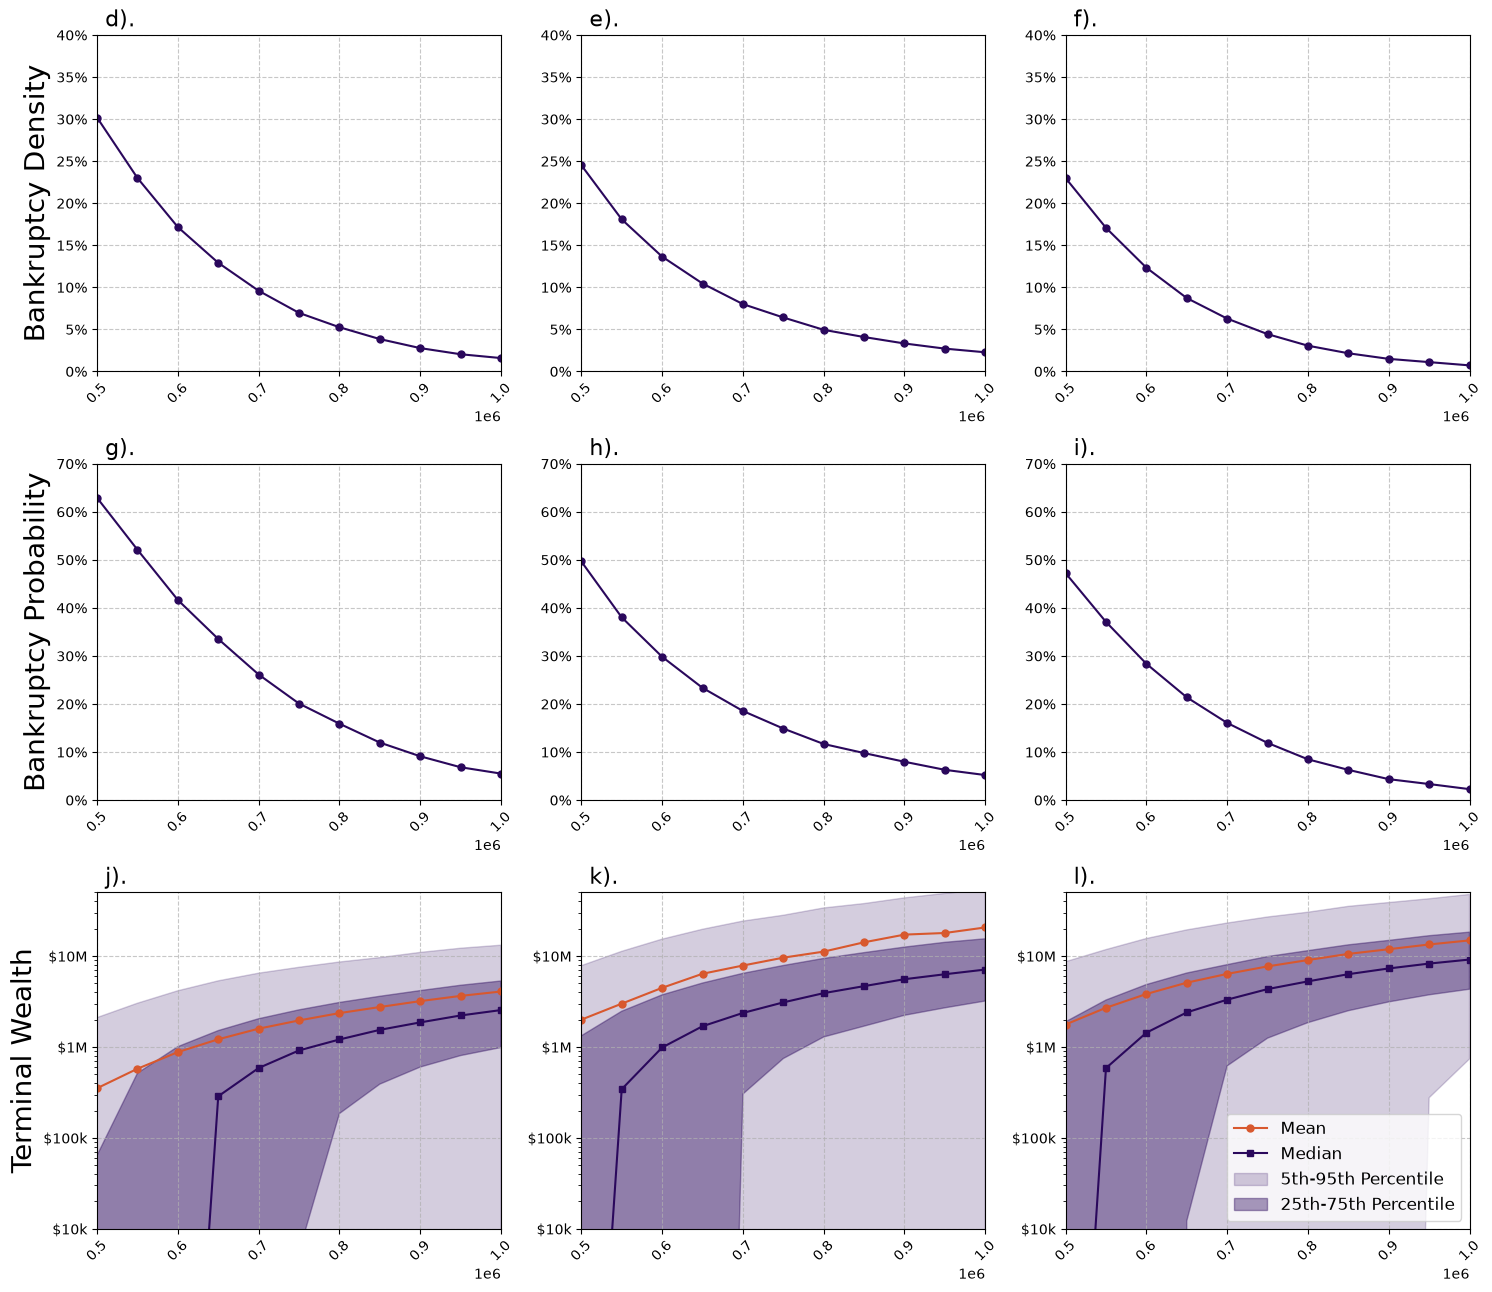

In [3]:
# Distributed initial-wealth case: replicate plots using simulated_initial_wealth
policy_data_dist = (
    best_policy_df
    .join(experiment_df, on='experiment_file')
    .filter(
        pl.col('initial_wealth').is_null()
        & (pl.col('n_wealth_nodes') == 1)
        & (pl.col('n_time_nodes') == 1
    ))
)
outcome_data_dist = (
    outcomes_df
    .join(experiment_df, on='experiment_file')
    .filter(
        pl.col('initial_wealth').is_null()
        & (pl.col('n_wealth_nodes') == 1)
        & (pl.col('n_time_nodes') == 1)
    )
)

fig, axes = plt.subplots(nrows=3, ncols=len(samplers_to_plot), figsize=(len(samplers_to_plot) * 5, 13))

for col_idx, sampler in enumerate(samplers_to_plot):
    this_outcome_data = outcome_data_dist.filter(pl.col('sampler') == sampler).sort('simulated_initial_wealth')

    x = np.array(this_outcome_data['simulated_initial_wealth'].to_list(), dtype=float)
    # Row 1: Bankruptcy density
    bd_axes = axes[0, col_idx]
    bd_axes.plot(x, this_outcome_data['bankruptcy_density'].to_list(), color=colors['Cash'], marker='o', markersize=5, label='Bankruptcy Density')
    if col_idx == 0:
        bd_axes.set_ylabel('Bankruptcy Density', fontsize=20)
    bd_axes.set_ylim(0, 0.4)
    bd_axes.set_xlim(min(x) if len(x) else 0, max(x) if len(x) else 1)
    bd_axes.grid(linestyle='--', alpha=0.7)
    bd_axes.yaxis.set_major_formatter(percent_formatter)
    bd_axes.tick_params(axis='x', rotation=45)
    bd_axes.text(0.02, 1.01, get_plot_letter(1, col_idx), transform=bd_axes.transAxes, fontsize=16, va='bottom', ha='left')

    # Row 2: Bankruptcy probability
    br_axes = axes[1, col_idx]
    br_axes.plot(x, this_outcome_data['bankruptcy_probability'].to_list(), color=colors['Cash'], marker='o', markersize=5, label='Bankruptcy Probability')
    if col_idx == 0:
        br_axes.set_ylabel('Bankruptcy Probability', fontsize=20)
    br_axes.set_ylim(0, 0.7)
    br_axes.set_xlim(min(x) if len(x) else 0, max(x) if len(x) else 1)
    br_axes.grid(linestyle='--', alpha=0.7)
    br_axes.yaxis.set_major_formatter(percent_formatter)
    br_axes.tick_params(axis='x', rotation=45)
    br_axes.text(0.02, 1.01, get_plot_letter(2, col_idx), transform=br_axes.transAxes, fontsize=16, va='bottom', ha='left')

    # Row 3: Mean terminal wealth
    mtw_axes = axes[2, col_idx]
    mtw_axes.plot(x, this_outcome_data['mean_terminal_wealth'].to_list(), color=colors['Stocks'], marker='o', markersize=5, label='Mean')
    mtw_axes.plot(x, (this_outcome_data['median_terminal_wealth'] + 1e-1).to_list(), color=colors['Cash'], marker='s', markersize=5, label='Median')
    mtw_axes.fill_between(x, this_outcome_data['p05_terminal_wealth'].to_list(), this_outcome_data['p95_terminal_wealth'].to_list(), color=colors['Cash'], alpha=0.2, label='5th-95th Percentile')
    mtw_axes.fill_between(x, this_outcome_data['p25_terminal_wealth'].to_list(), this_outcome_data['p75_terminal_wealth'].to_list(), color=colors['Cash'], alpha=0.4, label='25th-75th Percentile')
    mtw_axes.text(0.02, 1.01, get_plot_letter(3, col_idx), transform=mtw_axes.transAxes, fontsize=16, va='bottom', ha='left')
    if col_idx == 0:
        mtw_axes.set_ylabel('Terminal Wealth', fontsize=20)
    if col_idx == len(samplers_to_plot) - 1:
        mtw_axes.legend(loc='lower right', fontsize=12)
    mtw_axes.set_ylim(1e4, 5e7)
    mtw_axes.set_xlim(min(x) if len(x) else 0, max(x) if len(x) else 1)
    mtw_axes.grid(linestyle='--', alpha=0.7)
    mtw_axes.tick_params(axis='x', rotation=45)
    mtw_axes.set_yscale('log')
    mtw_axes.yaxis.set_major_formatter(currency_formatter)

fig.tight_layout(pad=1)
plt.savefig('./Plots/Fixed_Policy_Analysis_Distributed.png', dpi=300)


In [4]:
print(policy_data_dist.select(
        pl.col('sampler').alias('Returns Sample'),
        pl.col('cash').alias('Cash Allocation') * 100,
        pl.col('bonds').alias('Bonds Allocation') * 100,
        pl.col('stocks').alias('Stocks Allocation') * 100,
    )
    .to_pandas()
    .to_latex(
        index=False, 
        float_format="%.2f%%",
        caption="Optimised Fixed Allocation Strategies for Distributed Initial Wealth Case",
        label="tab:optimised_fixed_allocation_strategies_distributed_initial_wealth"
    )
)

ModuleNotFoundError: No module named 'pyarrow'

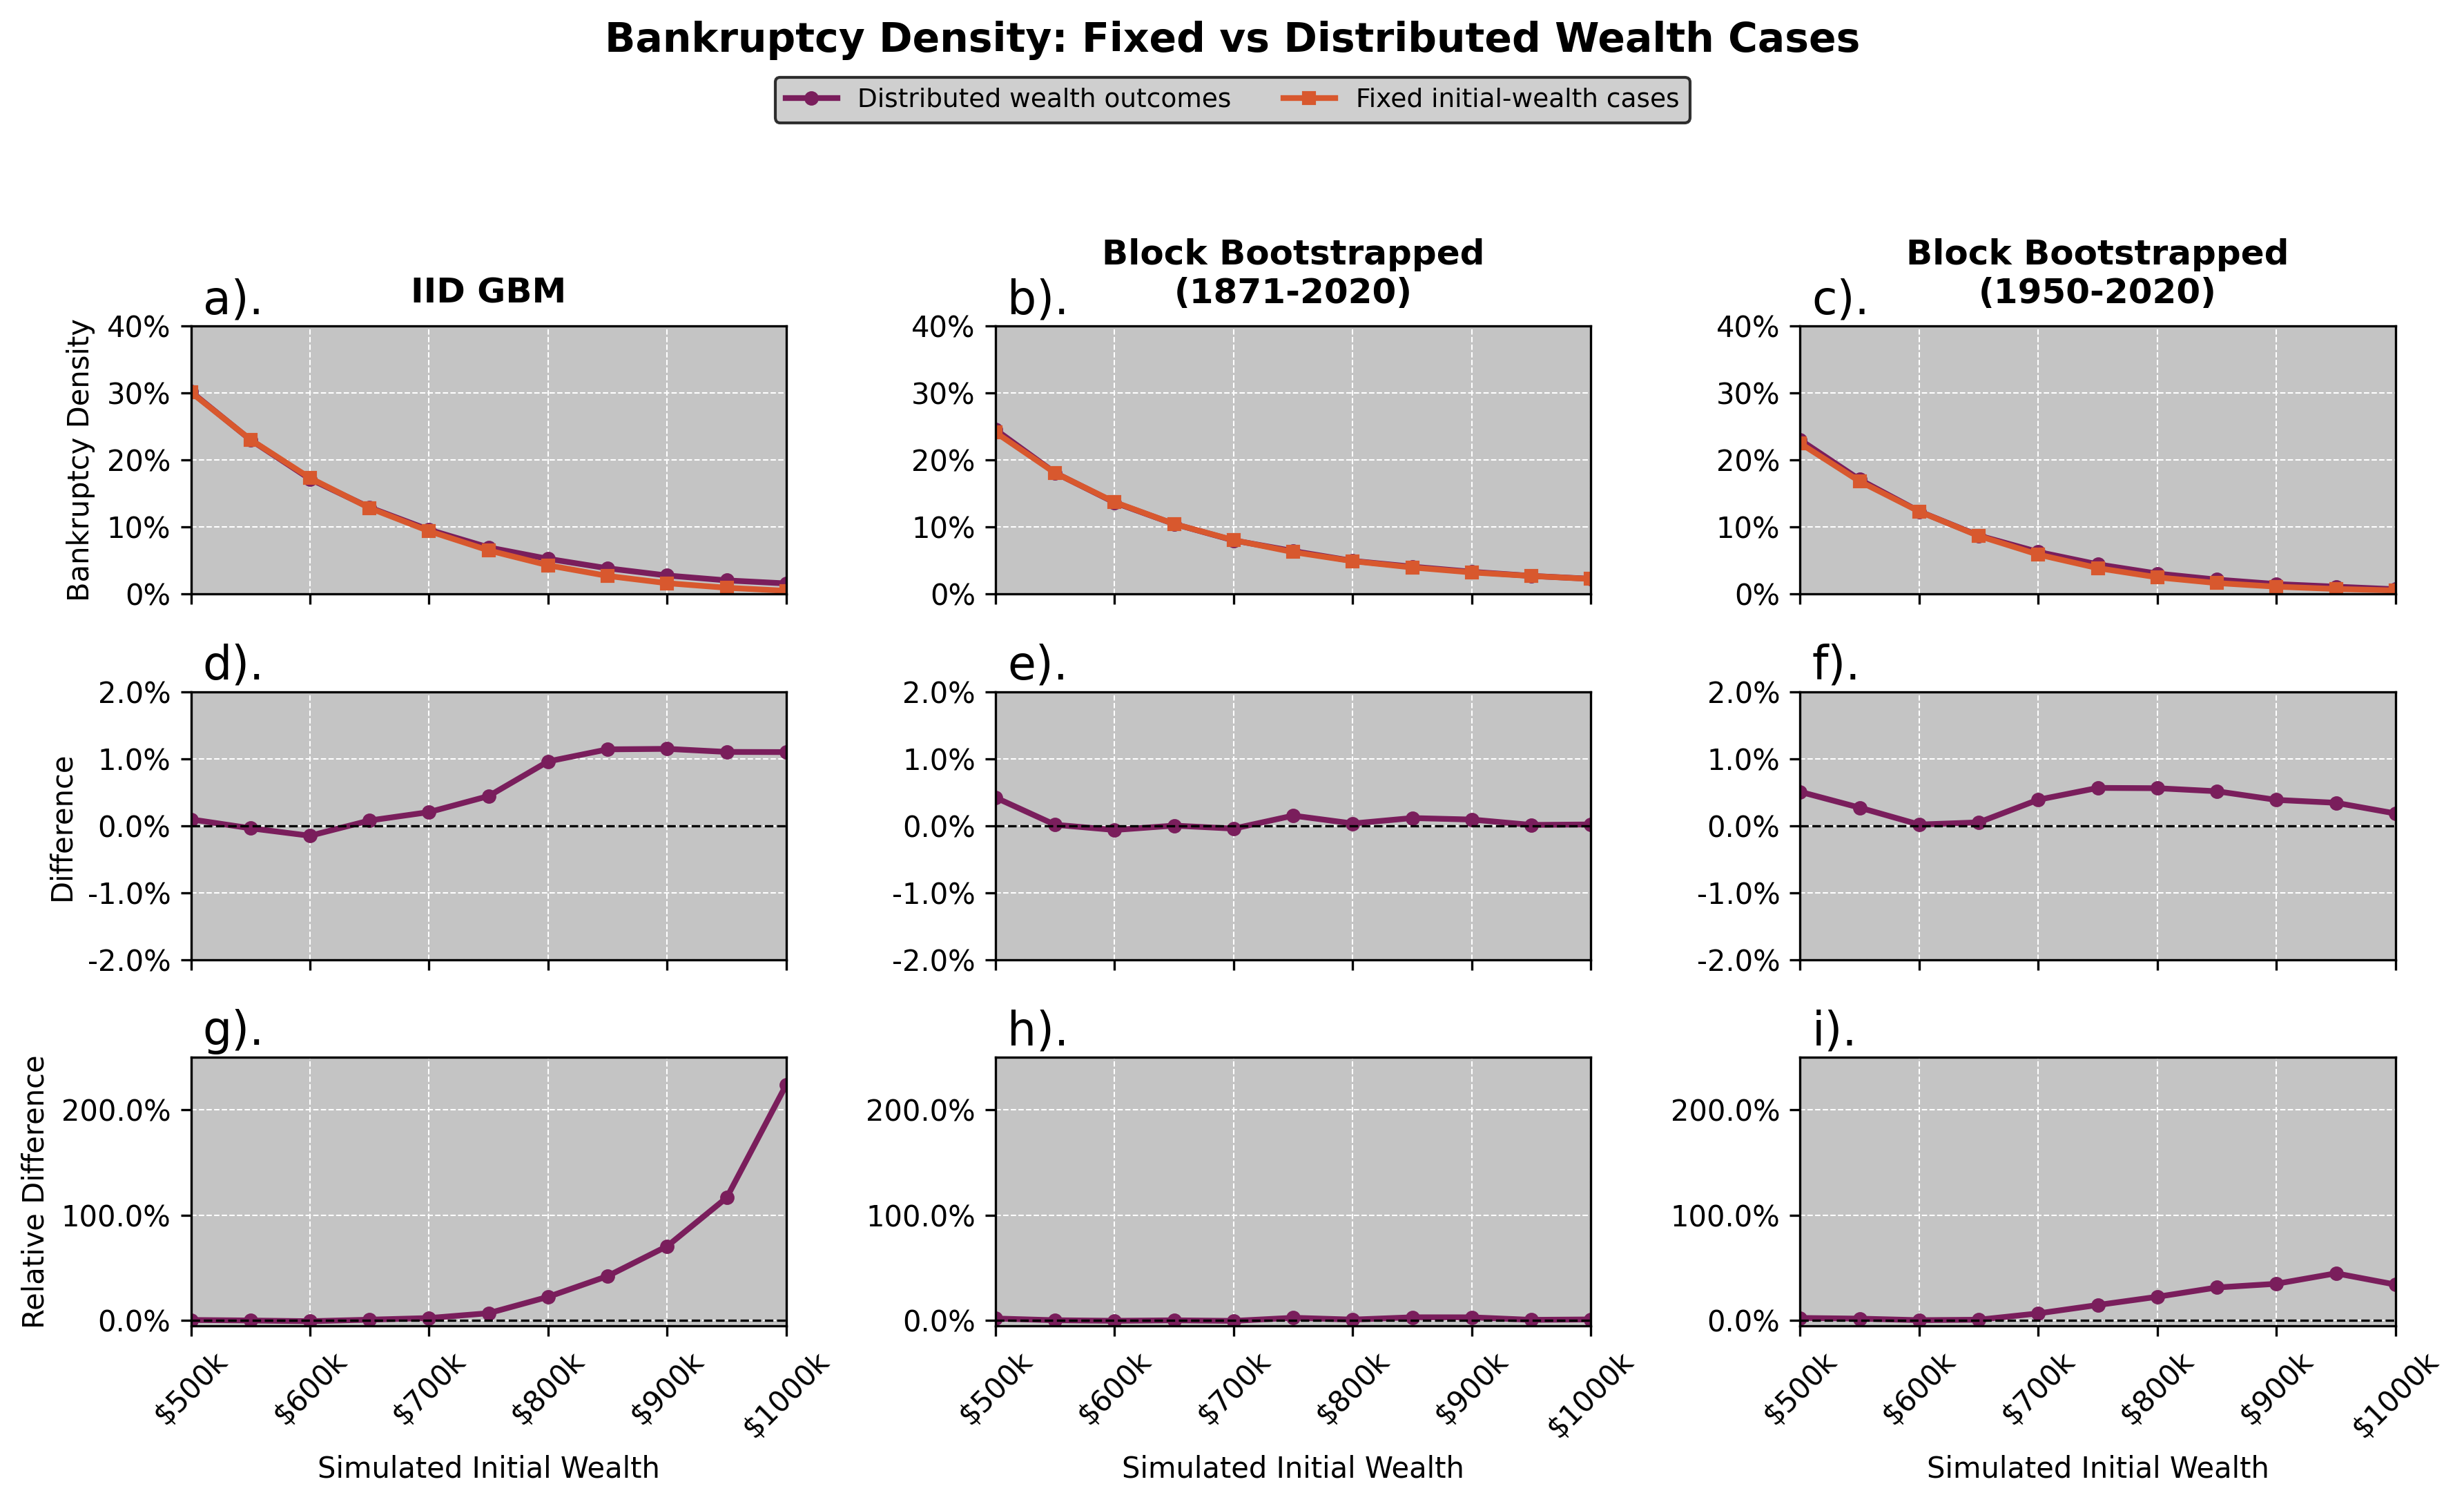

In [ ]:
def get_plot_letter(row_idx: int, col_idx: int, samplers_to_plot: list[str]) -> str:
    letter = chr(ord('a') + row_idx * len(samplers_to_plot) + col_idx)
    return f'{letter}).'


def plot_fixed_vs_distributed_metric(
    metric: str = 'bankruptcy_density',
    metric_label: str = 'Bankruptcy Density',
    *,
    bucket_width: float = 50_000.0,
    xlim: tuple[float, float] = (450_000, 1_050_000),
    top_ylim: tuple[float, float] | None = None,
    diff_ylim: tuple[float, float] | None = None,
    rel_diff_ylim: tuple[float, float] | None = None,
    distributed_label: str = 'Distributed wealth outcomes',
    fixed_label: str = 'Fixed initial-wealth cases',
    diff_label: str = 'Difference',
    rel_diff_label: str = 'Relative Difference',
    x_label: str = 'Simulated Initial Wealth',
    show_legend: bool = True,
    title: str | None = None,
) -> None:
    fixed_case = (
        outcomes_df.join(experiment_df, on='experiment_file')
        .filter((pl.col('n_wealth_nodes') == 1) & (pl.col('n_time_nodes') == 1))
    )

    fixed_known = fixed_case.filter(pl.col('initial_wealth').is_not_null())
    fixed_dist = fixed_case.filter(pl.col('initial_wealth').is_null())

    fig, axes = plt.subplots(
        3,
        len(samplers_to_plot),
        figsize=(12, 7),
        dpi=300,
        sharex=True,
        squeeze=False,
    )

    if len(samplers_to_plot) == 1:
        axes = axes.reshape(3, 1)

    for col_idx, sampler in enumerate(samplers_to_plot):
        known = fixed_known.filter(pl.col('sampler') == sampler).sort('initial_wealth')
        dist = fixed_dist.filter(pl.col('sampler') == sampler).sort('simulated_initial_wealth')

        x_known = np.asarray(known['initial_wealth'].to_list(), dtype=float)
        y_known = np.asarray(known[metric].to_list(), dtype=float)
        x_dist = np.asarray(dist['simulated_initial_wealth'].to_list(), dtype=float)
        y_dist = np.asarray(dist[metric].to_list(), dtype=float)

        mask_known = np.isfinite(x_known) & np.isfinite(y_known)
        mask_dist = np.isfinite(x_dist) & np.isfinite(y_dist)

        x_known = x_known[mask_known]
        y_known = y_known[mask_known]
        x_dist = x_dist[mask_dist]
        y_dist = y_dist[mask_dist]

        known_buckets = np.round(x_known / bucket_width) * bucket_width
        dist_buckets = np.round(x_dist / bucket_width) * bucket_width

        common_buckets, idx_known, idx_dist = np.intersect1d(
            known_buckets, dist_buckets, return_indices=True
        )
        if common_buckets.size == 0:
            continue

        x_common = x_dist[idx_dist]
        y_dist_aligned = y_dist[idx_dist]
        y_known_aligned = y_known[idx_known]

        ax_top = axes[0, col_idx]
        ax_mid = axes[1, col_idx]
        ax_bot = axes[2, col_idx]

        ax_top.plot(
            x_common,
            y_dist_aligned,
            color=colors['Bonds'],
            marker='o',
            linewidth=2,
            markersize=4,
            label=distributed_label,
        )
        ax_top.plot(
            x_common,
            y_known_aligned,
            color=colors['Stocks'],
            marker='s',
            linewidth=2,
            markersize=4,
            label=fixed_label,
        )
        ax_top.set_title(RETURN_SAMPLER_DISPLAY_NAMES[sampler], fontsize=12, fontweight='bold', pad=8)
        ax_top.grid(True, which='both', linestyle='--', linewidth=0.5, color='white')
        ax_top.set_facecolor('#c4c4c4')
        ax_top.text(0.02, 1.01, get_plot_letter(0, col_idx, samplers_to_plot), transform=ax_top.transAxes, fontsize=16, va='bottom', ha='left')

        diff = y_dist_aligned - y_known_aligned
        rel_diff = np.divide(
            diff,
            y_known_aligned,
            out=np.full_like(diff, np.nan, dtype=float),
            where=y_known_aligned != 0,
        )

        ax_mid.plot(x_common, diff, color=colors['Bonds'], marker='o', linewidth=2, markersize=4)
        ax_mid.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax_mid.grid(True, which='both', linestyle='--', linewidth=0.5, color='white')
        ax_mid.set_facecolor('#c4c4c4')
        ax_mid.text(0.02, 1.01, get_plot_letter(1, col_idx, samplers_to_plot), transform=ax_mid.transAxes, fontsize=16, va='bottom', ha='left')

        ax_bot.plot(x_common, rel_diff, color=colors['Bonds'], marker='o', linewidth=2, markersize=4)
        ax_bot.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax_bot.grid(True, which='both', linestyle='--', linewidth=0.5, color='white')
        ax_bot.set_facecolor('#c4c4c4')
        ax_bot.text(0.02, 1.01, get_plot_letter(2, col_idx, samplers_to_plot), transform=ax_bot.transAxes, fontsize=16, va='bottom', ha='left')

        if top_ylim is not None:
            ax_top.set_ylim(*top_ylim)
        if diff_ylim is not None:
            ax_mid.set_ylim(*diff_ylim)
        if rel_diff_ylim is not None:
            ax_bot.set_ylim(*rel_diff_ylim)
        ax_top.yaxis.set_major_formatter(percent_formatter)
        ax_mid.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
        ax_bot.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

    axes[0, 0].set_ylabel(metric_label, fontsize=10)
    axes[1, 0].set_ylabel(diff_label, fontsize=10)
    axes[2, 0].set_ylabel(rel_diff_label, fontsize=10)

    for ax in axes[-1, :]:
        ax.set_xlabel(x_label, fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlim(*xlim)
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k' if np.isfinite(x) else '')
        )

    for ax in axes.flatten():
        ax.set_xlim(*xlim)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='white')
        ax.set_facecolor('#c4c4c4')

    if show_legend:
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.0),
            ncol=2,
            fontsize=9,
            frameon=True,
            facecolor='#c4c4c4',
            edgecolor='black',
        )

    if title is not None:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.03)

    fig.tight_layout(rect=(0, 0, 1, 0.95))


plot_fixed_vs_distributed_metric(
    metric='bankruptcy_density',
    metric_label='Bankruptcy Density',
    top_ylim=(0, 0.4),
    diff_ylim=(-0.02, 0.02),
    rel_diff_ylim=(-0.05, 2.5),
    xlim=(500_000, 1_000_000),
    title='Bankruptcy Density: Fixed vs Distributed Wealth Cases',
)
plt.savefig('./Plots/Fixed_vs_Distributed_Bankruptcy_Density.png', dpi=300)
plt.show()
